# Stage 3

## Evaluasi Segmentasi
Tentukan tipe problem: klasifikasi <br>
Metrik : F1-Score, ROC-AUC karena data yang digunakan imbalanced.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_general = pd.read_csv('dataset/general_data.csv')
df_employee = pd.read_csv('dataset/employee_survey_data.csv')
df_manager = pd.read_csv('dataset/manager_survey_data.csv')
df_in_time = pd.read_csv('dataset/in_time.csv')
df_out_time = pd.read_csv('dataset/out_time.csv')

In [ ]:
cols_to_fix = df_in_time.columns[1:]

df_in_time[cols_to_fix] = df_in_time[cols_to_fix].apply(pd.to_datetime)
df_out_time[cols_to_fix] = df_out_time[cols_to_fix].apply(pd.to_datetime)
work_hours = df_out_time.iloc[:, 1:] - df_in_time.iloc[:, 1:]

In [ ]:
work_hours = (df_out_time.iloc[:, 1:] - df_in_time.iloc[:, 1:]) / pd.Timedelta(hours=1)
total_work_hours = work_hours.sum(axis=1)
average_work_hours = work_hours.mean(axis=1)

df_in_time.iloc[:, 1:] = df_in_time.iloc[:, 1:].apply(pd.to_datetime, errors='coerce')
df_out_time.iloc[:, 1:] = df_out_time.iloc[:, 1:].apply(pd.to_datetime, errors='coerce')

in_long = df_in_time.melt(id_vars=['Unnamed: 0'],
                     var_name='date',
                     value_name='in_time')

out_long = df_out_time.melt(id_vars=['Unnamed: 0'],
                       var_name='date',
                       value_name='out_time')

df = in_long.merge(out_long, on=['Unnamed: 0', 'date'])

df = df.dropna(subset=['in_time', 'out_time'])

df['work_hours'] = (df['out_time'] - df['in_time']).dt.total_seconds() / 3600

df = df[df['work_hours'] >= 0]

df['is_overwork'] = df['work_hours'] >= 9

overwork_days = df.groupby('Unnamed: 0')['is_overwork'].sum()
overwork_days = overwork_days.reset_index(drop=True)

In [ ]:
df_in_out = pd.concat(
    [total_work_hours, average_work_hours, overwork_days],
    axis=1
)

df_in_out.columns = ['total_work_hours', 'average_work_hours', 'overwork_days']
df_in_out = df_in_out.reset_index()

In [ ]:
df_in_out['overwork'] = df_in_out['total_work_hours'].apply(
    lambda x: 'Yes' if x > 2080 else 'No'
)

In [ ]:
df_in_out = df_in_out.drop(columns=['index'])

df_in_out.insert(0, 'EmployeeID', range(1, len(df_in_out) + 1))

In [ ]:
final_df = pd.merge(df_general, df_employee, on='EmployeeID')
final_df = pd.merge(final_df,df_manager, on='EmployeeID')
final_df = pd.merge(final_df,df_in_out, on='EmployeeID')

In [ ]:
final_df['Attrition'] = final_df['Attrition'].map({'Yes': 1, 'No': 0})
final_df['isMale'] = final_df['Gender'].map({'Male': 1, 'Female': 0})
final_df['overwork'] = final_df['overwork'].map({'Yes': 1, 'No': 0})

In [ ]:
final_df = pd.get_dummies(final_df, columns=['Department'],dtype=int, drop_first=True)
final_df = pd.get_dummies(final_df, columns=['EducationField'],dtype=int, drop_first=True)
final_df = pd.get_dummies(final_df, columns=['JobRole'],dtype=int, drop_first=True)
final_df = pd.get_dummies(final_df, columns=['MaritalStatus'],dtype=int, drop_first=True)
final_df = pd.get_dummies(final_df, columns=['BusinessTravel'],dtype=int, drop_first=True)

In [ ]:
final_df.head()

,Age,Attrition,DistanceFromHome,Education,EmployeeCount,EmployeeID,Gender,JobLevel,MonthlyIncome,NumCompaniesWorked,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely
0,51,0,6,2,1,1,Female,1,131160,1.0,...,0,0,0,0,0,0,1,0,0,1
1,31,1,10,1,1,2,Female,1,41890,0.0,...,0,0,0,1,0,0,0,1,1,0
2,32,0,17,4,1,3,Male,4,193280,1.0,...,0,0,0,0,1,0,1,0,1,0
3,38,0,2,5,1,4,Male,3,83210,3.0,...,0,0,0,0,0,0,1,0,0,0
4,32,0,10,1,1,5,Male,1,23420,4.0,...,0,0,0,0,1,0,0,1,0,1


## Split Dataset & Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split

y = final_df['Attrition']
X = final_df.drop(columns=['Attrition'])

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.4,
    random_state= 42,
    stratify=y
)

In [ ]:
X_train.fillna({'EnvironmentSatisfaction':X_train['EnvironmentSatisfaction'].mode()[0]}, inplace=True)
X_train.fillna({'JobSatisfaction':X_train['JobSatisfaction'].mode()[0]}, inplace=True)
X_train.fillna({'WorkLifeBalance':X_train['WorkLifeBalance'].mode()[0]}, inplace=True)
X_train.fillna({'NumCompaniesWorked':X_train['NumCompaniesWorked'].mode()[0]}, inplace=True)
X_train.fillna({'TotalWorkingYears':X_train['TotalWorkingYears'].mode()[0]}, inplace=True)

X_val.fillna({'EnvironmentSatisfaction':X_val['EnvironmentSatisfaction'].mode()[0]}, inplace=True)
X_val.fillna({'JobSatisfaction':X_val['JobSatisfaction'].mode()[0]}, inplace=True)
X_val.fillna({'WorkLifeBalance':X_val['WorkLifeBalance'].mode()[0]}, inplace=True)
X_val.fillna({'NumCompaniesWorked':X_val['NumCompaniesWorked'].mode()[0]}, inplace=True)
X_val.fillna({'TotalWorkingYears':X_val['TotalWorkingYears'].mode()[0]}, inplace=True)

X.fillna({'EnvironmentSatisfaction':X['EnvironmentSatisfaction'].mode()[0]}, inplace=True)
X.fillna({'JobSatisfaction':X['JobSatisfaction'].mode()[0]}, inplace=True)
X.fillna({'WorkLifeBalance':X['WorkLifeBalance'].mode()[0]}, inplace=True)
X.fillna({'NumCompaniesWorked':X['NumCompaniesWorked'].mode()[0]}, inplace=True)
X.fillna({'TotalWorkingYears':X['TotalWorkingYears'].mode()[0]}, inplace=True)

In [ ]:
X_train['DistanceFromHome_log'] = np.log1p(X_train['DistanceFromHome'])
X_train['MonthlyIncome_log'] = np.log1p(X_train['MonthlyIncome'])
X_train['NumCompaniesWorked_log'] = np.log1p(X_train['NumCompaniesWorked'])
X_train['PercentSalaryHike_log'] = np.log1p(X_train['PercentSalaryHike'])
X_train['TotalWorkingYears_log'] = np.log1p(X_train['TotalWorkingYears'])
X_train['YearsAtCompany_log'] = np.log1p(X_train['YearsAtCompany'])
X_train['YearsSinceLastPromotion_log'] = np.log1p(X_train['YearsSinceLastPromotion'])
X_train['YearsWithCurrManager_log'] = np.log1p(X_train['YearsWithCurrManager'])

X_val['DistanceFromHome_log'] = np.log1p(X_val['DistanceFromHome'])
X_val['MonthlyIncome_log'] = np.log1p(X_val['MonthlyIncome'])
X_val['NumCompaniesWorked_log'] = np.log1p(X_val['NumCompaniesWorked'])
X_val['PercentSalaryHike_log'] = np.log1p(X_val['PercentSalaryHike'])
X_val['TotalWorkingYears_log'] = np.log1p(X_val['TotalWorkingYears'])
X_val['YearsAtCompany_log'] = np.log1p(X_val['YearsAtCompany'])
X_val['YearsSinceLastPromotion_log'] = np.log1p(X_val['YearsSinceLastPromotion'])
X_val['YearsWithCurrManager_log'] = np.log1p(X_val['YearsWithCurrManager'])

X['DistanceFromHome_log'] = np.log1p(X['DistanceFromHome'])
X['MonthlyIncome_log'] = np.log1p(X['MonthlyIncome'])
X['NumCompaniesWorked_log'] = np.log1p(X['NumCompaniesWorked'])
X['PercentSalaryHike_log'] = np.log1p(X['PercentSalaryHike'])
X['TotalWorkingYears_log'] = np.log1p(X['TotalWorkingYears'])
X['YearsAtCompany_log'] = np.log1p(X['YearsAtCompany'])
X['YearsSinceLastPromotion_log'] = np.log1p(X['YearsSinceLastPromotion'])
X['YearsWithCurrManager_log'] = np.log1p(X['YearsWithCurrManager'])

In [ ]:
X_train = X_train.drop(columns= ['EmployeeID','DistanceFromHome','Gender','MonthlyIncome','NumCompaniesWorked','PercentSalaryHike',
                                   'TotalWorkingYears','YearsAtCompany','YearsAtCompany','YearsSinceLastPromotion','YearsWithCurrManager',
                                   'TotalWorkingYears_log','YearsSinceLastPromotion_log','YearsWithCurrManager_log',
                                   'average_work_hours','overwork_days','overwork','StandardHours','EmployeeCount','Over18'])
X_val = X_val.drop(columns= ['EmployeeID','DistanceFromHome','Gender','MonthlyIncome','NumCompaniesWorked','PercentSalaryHike',
                                   'TotalWorkingYears','YearsAtCompany','YearsAtCompany','YearsSinceLastPromotion','YearsWithCurrManager',
                                   'TotalWorkingYears_log','YearsSinceLastPromotion_log','YearsWithCurrManager_log',
                                   'average_work_hours','overwork_days','overwork','StandardHours','EmployeeCount','Over18'])
X = X.drop(columns= ['EmployeeID','DistanceFromHome','Gender','MonthlyIncome','NumCompaniesWorked','PercentSalaryHike',
                                   'TotalWorkingYears','YearsAtCompany','YearsAtCompany','YearsSinceLastPromotion','YearsWithCurrManager',
                                   'TotalWorkingYears_log','YearsSinceLastPromotion_log','YearsWithCurrManager_log',
                                   'average_work_hours','overwork_days','overwork','StandardHours','EmployeeCount','Over18'])

## Modeling

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_validate

def eval_classification(model):
    # prediction
    y_pred = model.predict(X_val)
    y_pred_train = model.predict(X_train)

    # probability
    y_proba = model.predict_proba(X_val)[:,1]
    y_proba_train = model.predict_proba(X_train)[:,1]

    # metrics
    print("Accuracy (val Set): %.2f" % accuracy_score(y_val, y_pred))
    print("Accuracy (Train Set): %.2f" % accuracy_score(y_train, y_pred_train))
    print("Precision (val Set): %.2f" % precision_score(y_val, y_pred))
    print("Recall (val Set): %.2f" % recall_score(y_val, y_pred))
    print("F1-Score (val Set): %.2f" % f1_score(y_val, y_pred))
    print("roc_auc (val): %.2f" % roc_auc_score(y_val, y_proba))
    print("roc_auc (train): %.2f" % roc_auc_score(y_train, y_proba_train))

    score = cross_validate(model, X, y, cv=5, scoring='recall', return_train_score=True)
    print('recall (cv train):', score['train_score'].mean())
    print('recall (cv test):', score['test_score'].mean())

def show_feature_importance(model):
    feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
    ax = feat_importances.nlargest(25).plot(kind='barh', figsize=(10, 8))
    ax.invert_yaxis()

    plt.xlabel('score')
    plt.ylabel('feature')
    plt.title('feature importance score')

def show_best_hyperparameter(model):
    print(model.best_estimator_.get_params())

### CatBoost

In [ ]:
from catboost import CatBoostClassifier
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# pipeline
pipeline_catboost = Pipeline([
    ('scaler', StandardScaler()),
    ('model', CatBoostClassifier(
        random_state=42,
        verbose=0
    ))
])

# train model
pipeline_catboost.fit(X_train, y_train)

# prediction
y_pred = pipeline_catboost.predict(X_val)

# evaluation
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1480
           1       0.97      0.77      0.86       284

    accuracy                           0.96      1764
   macro avg       0.97      0.88      0.92      1764
weighted avg       0.96      0.96      0.96      1764



In [ ]:
eval_classification(pipeline_catboost)

Accuracy (val Set): 0.96
Accuracy (Train Set): 1.00
Precision (val Set): 0.97
Recall (val Set): 0.77
F1-Score (val Set): 0.86
roc_auc (val): 0.96
roc_auc (train): 1.00
recall (cv train): 0.9799574246887299
recall (cv test): 0.9507830197971042


In [ ]:
print(confusion_matrix(y_val, pipeline_catboost.predict(X_val)))

[[1474    6]
 [  65  219]]


#### Paramater Tuning

In [ ]:
# pipeline
pipeline_catboost = Pipeline([
    ('scaler', StandardScaler()),
    ('model', CatBoostClassifier(
        random_state=42,
        verbose=0
    ))
])

# hyperparameter tuning
param_catboost = {
    'model__iterations': [100, 200, 300, 500],
    'model__depth': [4, 6, 8, 10],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__l2_leaf_reg': [1, 3, 5, 7, 9],
    'model__border_count': [32, 64, 128, 255],
    'model__bagging_temperature': [0, 1, 3, 5],
    'model__random_strength': [1, 2, 5, 10]
}

# randomized search
search_catboost = RandomizedSearchCV(
    estimator=pipeline_catboost,
    param_distributions=param_catboost,
    n_iter=20,
    scoring='recall',   # focus on increasing recall
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# training
search_catboost.fit(X_train, y_train)

# best model
best_catboost = search_catboost.best_estimator_

# prediction
y_pred = best_catboost.predict(X_val)

# evaluation
print("Best Parameters:")
print(search_catboost.best_params_)

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'model__random_strength': 5, 'model__learning_rate': 0.2, 'model__l2_leaf_reg': 3, 'model__iterations': 500, 'model__depth': 4, 'model__border_count': 32, 'model__bagging_temperature': 1}

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1480
           1       0.96      0.85      0.90       284

    accuracy                           0.97      1764
   macro avg       0.97      0.92      0.94      1764
weighted avg       0.97      0.97      0.97      1764



In [ ]:
eval_classification(search_catboost)

Accuracy (val Set): 0.97
Accuracy (Train Set): 1.00
Precision (val Set): 0.96
Recall (val Set): 0.85
F1-Score (val Set): 0.90
roc_auc (val): 0.95
roc_auc (train): 1.00
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
recall (cv train): 1.0
recall (cv test): 0.9985915492957746


In [ ]:
print(confusion_matrix(y_val, search_catboost.predict(X_val)))

[[1470   10]
 [  42  242]]


#### Feature Importance

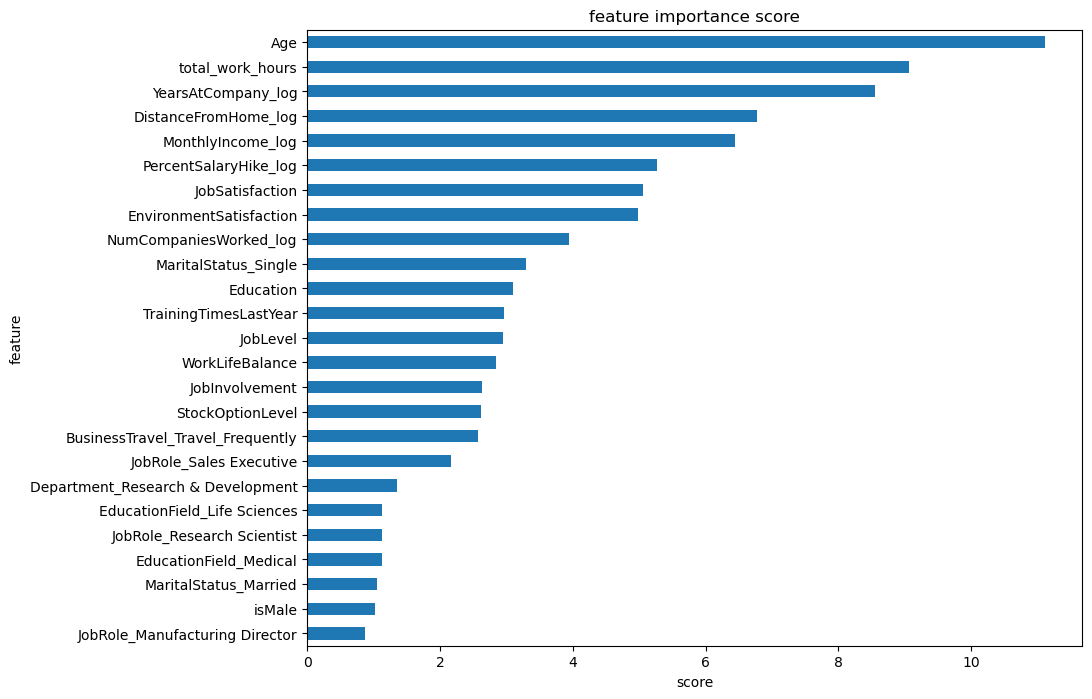

In [ ]:
# ambil model decision tree dari pipeline
cat_model = search_catboost.best_estimator_.named_steps['model']

# tampilkan feature importance
show_feature_importance(cat_model)

In [ ]:
def show_feature_top5(model):
    feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
    ax = feat_importances.nlargest(5).plot(kind='barh', figsize=(10, 8))
    ax.invert_yaxis()

    plt.xlabel('score')
    plt.ylabel('feature')
    plt.title('Top 5 feature importance score')

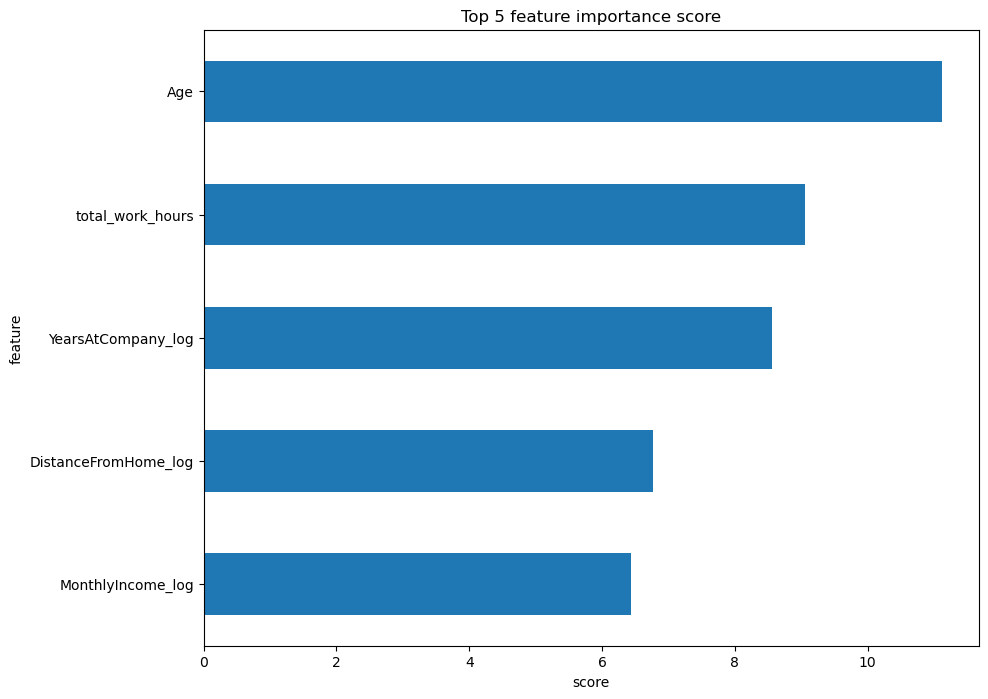

In [ ]:
# ambil model decision tree dari pipeline
cat_model = search_catboost.best_estimator_.named_steps['model']

# tampilkan feature importance
show_feature_top5(cat_model)

#### SHAP

PermutationExplainer explainer: 1765it [01:14, 21.68it/s]                          
C:\Users\Reckt\AppData\Local\Temp\ipykernel_3856\620964434.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


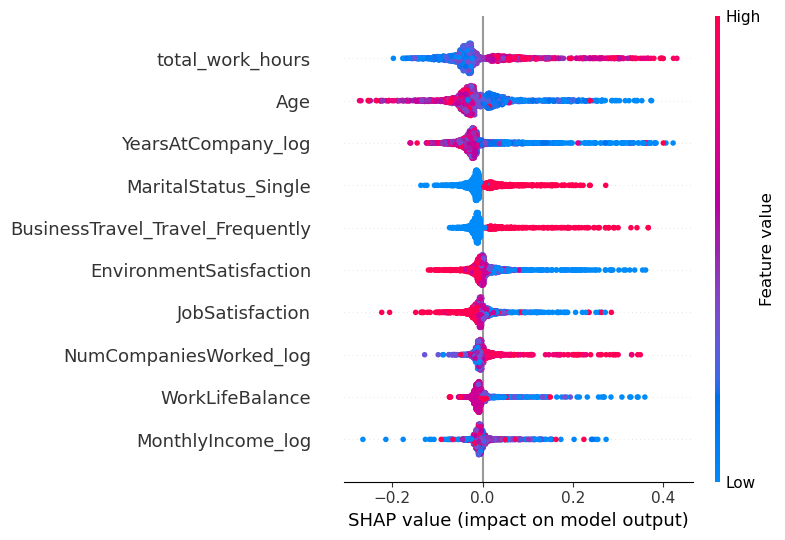

In [ ]:
import shap

# ambil pipeline terbaik
cat_model = search_catboost.best_estimator_

# explainer
explainer = shap.Explainer(
    cat_model.predict,
    X_val
)

# shap values
shap_values = explainer(X_val)

# summary plot
shap.summary_plot(
    shap_values,
    X_val,
    max_display=10
)

## Age Evaluation

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
import pandas as pd

# Prediksi probabilitas
y_proba = best_catboost.predict_proba(X_val)[:, 1]

# Gabungkan data evaluasi
evaluation_df = X_val.copy()

evaluation_df['Actual'] = y_val.values
evaluation_df['Prediction'] = y_pred
evaluation_df['Probability'] = y_proba

# Membuat segmentasi berdasarkan Age
evaluation_df['Age_Group'] = pd.cut(
    evaluation_df['Age'],
    bins=[18, 30, 40, 50, 60],
    labels=['18-30', '31-40', '41-50', '51-60']
)

# Menyimpan hasil evaluasi
results = []

# Evaluasi tiap kelompok usia
for age_group in evaluation_df['Age_Group'].dropna().unique():

    subset = evaluation_df[
        evaluation_df['Age_Group'] == age_group
    ]

    results.append({
        'Age_Group': age_group,
        'Accuracy': accuracy_score(
            subset['Actual'],
            subset['Prediction']
        ),
        'Precision': precision_score(
            subset['Actual'],
            subset['Prediction'],
            zero_division=0
        ),
        'Recall': recall_score(
            subset['Actual'],
            subset['Prediction'],
            zero_division=0
        ),
        'F1-Score': f1_score(
            subset['Actual'],
            subset['Prediction'],
            zero_division=0
        ),
        'ROC-AUC': roc_auc_score(
            subset['Actual'],
            subset['Probability']
        ),
        'Total_Data': len(subset)
    })

# Membuat dataframe hasil
results_df = pd.DataFrame(results)

# Urutkan berdasarkan kelompok usia
results_df = results_df.sort_values('Age_Group')

# Tampilkan hasil
results_df

,Age_Group,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Total_Data
0,18-30,0.984234,0.946429,0.990654,0.968037,0.997892,444
1,31-40,0.964567,0.954545,0.785047,0.861538,0.938560,762
2,41-50,0.960422,1.000000,0.673913,0.805195,0.848348,379
3,51-60,0.982558,1.000000,0.857143,0.923077,0.982025,172


### Business Insight



## Work Hours Evaluation

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
import pandas as pd

# Prediksi probabilitas
y_proba = best_catboost.predict_proba(X_val)[:, 1]

# Gabungkan data evaluasi
evaluation_df = X_val.copy()

evaluation_df['Actual'] = y_val.values
evaluation_df['Prediction'] = y_pred
evaluation_df['Probability'] = y_proba

# Segmentasi berdasarkan Total Work Hours
evaluation_df['Work_Hours_Group'] = pd.cut(
    evaluation_df['total_work_hours'],
    bins=[0, 1500, 2000, 2500, 3000],
    labels=[
        '0-1500 Hours',
        '1501-2000 Hours',
        '2001-2500 Hours',
        '2501-3000 Hours'
    ]
)

# Menyimpan hasil evaluasi
results = []

# Evaluasi tiap kelompok jam kerja
for group in evaluation_df['Work_Hours_Group'].dropna().unique():

    subset = evaluation_df[
        evaluation_df['Work_Hours_Group'] == group
    ]

    results.append({
        'Work_Hours_Group': group,
        'Accuracy': accuracy_score(
            subset['Actual'],
            subset['Prediction']
        ),
        'Precision': precision_score(
            subset['Actual'],
            subset['Prediction'],
            zero_division=0
        ),
        'Recall': recall_score(
            subset['Actual'],
            subset['Prediction'],
            zero_division=0
        ),
        'F1-Score': f1_score(
            subset['Actual'],
            subset['Prediction'],
            zero_division=0
        ),
        'ROC-AUC': roc_auc_score(
            subset['Actual'],
            subset['Probability']
        ),
        'Total_Data': len(subset)
    })

# Membuat dataframe hasil
results_df = pd.DataFrame(results)

# Urutkan berdasarkan kelompok jam kerja
results_df = results_df.sort_values('Work_Hours_Group')

# Tampilkan hasil
results_df

,Work_Hours_Group,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Total_Data
1,0-1500 Hours,1.000000,1.000000,1.000000,1.000000,1.000000,300
0,1501-2000 Hours,0.979769,0.937008,0.901515,0.918919,0.952020,1038
2,2001-2500 Hours,0.927900,0.973684,0.778947,0.865497,0.884492,319
3,2501-3000 Hours,0.925234,1.000000,0.750000,0.857143,0.966667,107


### Business Insight



## Tenure Evaluation

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
import pandas as pd

# Prediksi probabilitas
y_proba = best_catboost.predict_proba(X_val)[:, 1]

# Gabungkan data evaluasi
evaluation_df = X_val.copy()

evaluation_df['Actual'] = y_val.values
evaluation_df['Prediction'] = y_pred
evaluation_df['Probability'] = y_proba

# Segmentasi berdasarkan tenure
evaluation_df['Tenure_Group'] = pd.cut(
    evaluation_df['YearsAtCompany_log'],
    bins=[0, 1, 2, 3, 5],
    labels=[
        'Low Tenure',
        'Medium Tenure',
        'High Tenure',
        'Very High Tenure'
    ],
    ordered=True
)

# Menyimpan hasil evaluasi
results = []

# Evaluasi tiap kelompok tenure
for group in evaluation_df['Tenure_Group'].dropna().unique():

    subset = evaluation_df[
        evaluation_df['Tenure_Group'] == group
    ]

    results.append({
        'Tenure_Group': group,
        'Accuracy': accuracy_score(
            subset['Actual'],
            subset['Prediction']
        ),
        'Precision': precision_score(
            subset['Actual'],
            subset['Prediction'],
            zero_division=0
        ),
        'Recall': recall_score(
            subset['Actual'],
            subset['Prediction'],
            zero_division=0
        ),
        'F1-Score': f1_score(
            subset['Actual'],
            subset['Prediction'],
            zero_division=0
        ),
        'ROC-AUC': roc_auc_score(
            subset['Actual'],
            subset['Probability']
        ),
        'Total_Data': len(subset)
    })

# Membuat dataframe hasil
results_df = pd.DataFrame(results)

# Sorting berdasarkan urutan tenure
tenure_order = [
    'Low Tenure',
    'Medium Tenure',
    'High Tenure',
    'Very High Tenure'
]

results_df['Tenure_Group'] = pd.Categorical(
    results_df['Tenure_Group'],
    categories=tenure_order,
    ordered=True
)

results_df = results_df.sort_values('Tenure_Group')

# Tampilkan hasil
results_df

,Tenure_Group,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Total_Data
2,Low Tenure,0.984772,1.0000,0.950820,0.974790,0.975289,197
1,Medium Tenure,0.966013,0.9375,0.846774,0.889831,0.962823,765
0,High Tenure,0.977742,1.0000,0.787879,0.881356,0.942112,629
3,Very High Tenure,0.951220,1.0000,0.625000,0.769231,0.698014,123


### Business Insight



## Marital Status Evaluation

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
import pandas as pd

# Prediksi probabilitas
y_proba = best_catboost.predict_proba(X_val)[:, 1]

# Gabungkan data evaluasi
evaluation_df = X_val.copy()

evaluation_df['Actual'] = y_val.values
evaluation_df['Prediction'] = y_pred
evaluation_df['Probability'] = y_proba

# Membuat segmentasi marital status
evaluation_df['Marital_Status'] = evaluation_df[
    'MaritalStatus_Single'
].map({
    1: 'Single',
    0: 'Non-Single'
})

# Menyimpan hasil evaluasi
results = []

# Evaluasi tiap marital status
for status in evaluation_df['Marital_Status'].dropna().unique():

    subset = evaluation_df[
        evaluation_df['Marital_Status'] == status
    ]

    results.append({
        'Marital_Status': status,
        'Accuracy': accuracy_score(
            subset['Actual'],
            subset['Prediction']
        ),
        'Precision': precision_score(
            subset['Actual'],
            subset['Prediction'],
            zero_division=0
        ),
        'Recall': recall_score(
            subset['Actual'],
            subset['Prediction'],
            zero_division=0
        ),
        'F1-Score': f1_score(
            subset['Actual'],
            subset['Prediction'],
            zero_division=0
        ),
        'ROC-AUC': roc_auc_score(
            subset['Actual'],
            subset['Probability']
        ),
        'Total_Data': len(subset)
    })

# Membuat dataframe hasil
results_df = pd.DataFrame(results)

# Sorting
marital_order = ['Single', 'Non-Single']

results_df['Marital_Status'] = pd.Categorical(
    results_df['Marital_Status'],
    categories=marital_order,
    ordered=True
)

results_df = results_df.sort_values('Marital_Status')

# Tampilkan hasil
results_df

,Marital_Status,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Total_Data
1,Single,0.973404,0.948529,0.941606,0.945055,0.962752,564
0,Non-Single,0.969167,0.974138,0.768707,0.859316,0.932935,1200


### Business Insight



## Income Evaluation

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
import pandas as pd

# Prediksi probabilitas
y_proba = best_catboost.predict_proba(X_val)[:, 1]

# Gabungkan data evaluasi
evaluation_df = X_val.copy()

evaluation_df['Actual'] = y_val.values
evaluation_df['Prediction'] = y_pred
evaluation_df['Probability'] = y_proba

# Segmentasi berdasarkan Monthly Income asli
evaluation_df['Income_Group'] = pd.cut(
    evaluation_df['MonthlyIncome_log'],
    bins=[9, 10, 11, 12, 13],
    labels=[
        'Low Income',
        'Medium Income',
        'High Income',
        'Very High Income'
    ],
    ordered=True
)

# Menyimpan hasil evaluasi
results = []

# Evaluasi tiap kelompok income
for group in evaluation_df['Income_Group'].dropna().unique():

    subset = evaluation_df[
        evaluation_df['Income_Group'] == group
    ]

    results.append({
        'Income_Group': group,
        'Accuracy': accuracy_score(
            subset['Actual'],
            subset['Prediction']
        ),
        'Precision': precision_score(
            subset['Actual'],
            subset['Prediction'],
            zero_division=0
        ),
        'Recall': recall_score(
            subset['Actual'],
            subset['Prediction'],
            zero_division=0
        ),
        'F1-Score': f1_score(
            subset['Actual'],
            subset['Prediction'],
            zero_division=0
        ),
        'ROC-AUC': roc_auc_score(
            subset['Actual'],
            subset['Probability']
        ),
        'Total_Data': len(subset)
    })

# Membuat dataframe hasil
results_df = pd.DataFrame(results)

# Sorting berdasarkan income
income_order = [
    'Low Income',
    'Medium Income',
    'High Income',
    'Very High Income'
]

results_df['Income_Group'] = pd.Categorical(
    results_df['Income_Group'],
    categories=income_order,
    ordered=True
)

results_df = results_df.sort_values('Income_Group')

# Tampilkan hasil
results_df

,Income_Group,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Total_Data
3,Low Income,1.000000,1.000000,1.000000,1.000000,1.000000,118
0,Medium Income,0.975232,0.971223,0.870968,0.918367,0.961053,969
1,High Income,0.959032,0.921053,0.813953,0.864198,0.928067,537
2,Very High Income,0.957143,1.000000,0.647059,0.785714,0.807269,140


### Business Insight

